In [16]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [17]:
!pip install split-folders


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import splitfolders

splitfolders.ratio(
    "../PlantDataset",           # 👈 go one level up
    output="../data/rice_disease",
    seed=42,
    ratio=(0.7, 0.2, 0.1)
)

Copying files: 120 files [00:00, 334.79 files/s]


In [19]:
BASE_DIR = Path("../data/rice_disease")

train_dir = BASE_DIR / "train"
val_dir = BASE_DIR / "val"
test_dir = BASE_DIR / "test"

print(train_dir.exists(), val_dir.exists(), test_dir.exists())

True True True


In [20]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 8

train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2], # 🔥 Added brightness
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator()

In [21]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 84 images belonging to 3 classes.
Found 24 images belonging to 3 classes.


Found 12 images belonging to 3 classes.
Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [22]:
def build_transfer_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(128, 128, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze base

    model = models.Sequential([
        layers.Input(shape=(128, 128, 3)),
        # MobileNetV2 expects [-1, 1] range
        layers.Rescaling(1./127.5, offset=-1),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(len(class_names), activation='softmax')
    ])

    return model

model = build_transfer_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

print("Training head...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Training head...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 676ms/step - accuracy: 0.4405 - loss: 1.2479 - val_accuracy: 0.4167 - val_loss: 1.4163 - learning_rate: 1.0000e-04
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 255ms/step - accuracy: 0.4643 - loss: 1.2002 - val_accuracy: 0.4167 - val_loss: 1.3584 - learning_rate: 1.0000e-04
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.3095 - loss: 1.4654 - val_accuracy: 0.4167 - val_loss: 1.3078 - learning_rate: 1.0000e-04
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - accuracy: 0.4405 - loss: 1.2138 - val_accuracy: 0.4167 - val_loss: 1.2643 - learning_rate: 1.0000e-04
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.4048 - loss: 1.3160 - val_accuracy: 0.4583 - val_loss: 1.2296 - learning_rate: 1.0000e-04
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.4405 - loss: 1.1423 - val_accuracy: 0.5000 - val_loss: 1.1909 - learning_rate: 1.0000e-04
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms

### Fine-tuning the Model
Now we unfreeze the top layers of the base model to allow it to adapt to our specific rice disease features.

In [25]:
# Unfreeze the base model
base_model = model.layers[1] # MobileNetV2 is the second layer (index 1)
base_model.trainable = True

# Let's see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Number of layers in the base model:  154


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 1,865,283 (7.12 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [26]:
print("Fine-tuning...")
fine_tune_epochs = 50
total_epochs = 50 + fine_tune_epochs

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    callbacks=[early_stop, reduce_lr]
)

Fine-tuning...
Epoch 50/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 485ms/step - accuracy: 0.3571 - loss: 1.3131 - val_accuracy: 0.9167 - val_loss: 0.4689 - learning_rate: 1.0000e-05
Epoch 51/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 237ms/step - accuracy: 0.5238 - loss: 1.0565 - val_accuracy: 0.9167 - val_loss: 0.4566 - learning_rate: 1.0000e-05
Epoch 52/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.5714 - loss: 0.9178 - val_accuracy: 0.9167 - val_loss: 0.4493 - learning_rate: 1.0000e-05
Epoch 53/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.5833 - loss: 0.9856 - val_accuracy: 0.9167 - val_loss: 0.4344 - learning_rate: 1.0000e-05
Epoch 54/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.5952 - loss: 0.9430 - val_accuracy: 0.9167 - val_loss: 0.4274 - learning_rate: 1.0000e-05
Epoch 55/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.5476 - loss: 0.9203 - val_accuracy: 0.9167 - val_loss: 0.4199 - learning_rate: 1.0000e-05
Epoch 56/100
11/11 ━━━━━━━━━━━━━━━━━

### Model Evaluation
Let's see how the model performs on the test set.

In [27]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.1418 
Test Accuracy: 100.00%
Test Loss: 0.1418


### Save the Model

In [28]:
model.save("../models/rice_disease_model.keras")
print("Model saved as rice_disease_model.keras")

Model saved as rice_disease_model.keras


### Training Curves

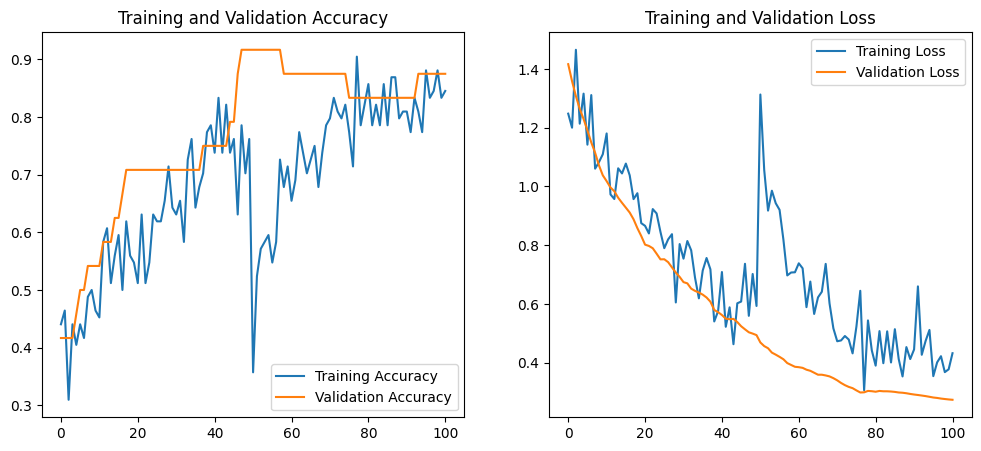

In [29]:
def plot_history(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

# If history_fine exists, we combine them
if 'history_fine' in globals():
    all_acc = history.history['accuracy'] + history_fine.history['accuracy']
    all_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
    all_loss = history.history['loss'] + history_fine.history['loss']
    all_val_loss = history.history['val_loss'] + history_fine.history['val_loss']
    
    combined_history = type('obj', (object,), {
        'history': {
            'accuracy': all_acc, 
            'val_accuracy': all_val_acc, 
            'loss': all_loss, 
            'val_loss': all_val_loss
        }
    })
    plot_history(combined_history)
else:
    plot_history(history)

### Visualize Predictions
Let's see the model in action on some test images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


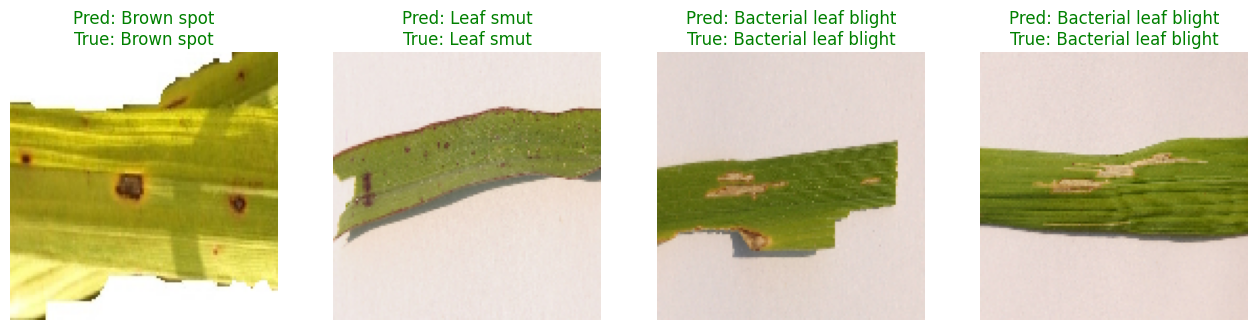

In [31]:
def visualize_predictions(model, generator, class_names, num_images=8):
    images, labels = next(generator)
    preds = model.predict(images)
    
    plt.figure(figsize=(16, 16))
    for i in range(min(len(images), num_images)):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].astype("uint8") if images[i].max() > 1 else images[i])
        
        pred_idx = np.argmax(preds[i])
        true_idx = np.argmax(labels[i])
        
        color = 'green' if pred_idx == true_idx else 'red'
        plt.title(f"Pred: {class_names[pred_idx]}\nTrue: {class_names[true_idx]}", color=color)
        plt.axis("off")
    plt.show()

visualize_predictions(model, test_generator, class_names)